##Lecture 25 Practical Exercise 1


In [11]:
import tensorflow as tf
from keras import layers, Model
import matplotlib.pyplot as plt

In [12]:
(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()

In [13]:
x_train=x_train.astype('float32') / 255
x_test=x_test.astype('float32') / 255

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
# print("x_train (1st row):",x_train[0])

x_train shape: (60000, 784)
x_test shape: (10000, 784)


Sampling Layer in the Encoder

In [14]:
class Sampling(layers.Layer):
  def call(self,inputs):
    z_mean,z_log_var=inputs
    epsilon=tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Encoder

In [15]:
latent_dim=16
encoder_inputs=layers.Input(shape=(784,))
x=layers.Dense(256,activation='relu')(encoder_inputs)
z_mean=layers.Dense(latent_dim,name="z_mean")(x)
z_log_var=layers.Dense(latent_dim,name='z_log_var')(x)
z=Sampling()([z_mean,z_log_var])
encoder=Model(
    encoder_inputs,
    [z_mean,z_log_var,z],
    name='encoder'
)

Decoder

In [16]:
latent_inputs=layers.Input(shape=(latent_dim,))
x=layers.Dense(256,activation='relu')(latent_inputs)
decoder_outputs=layers.Dense(784,activation='sigmoid')(x)
decoder=Model(latent_inputs,decoder_outputs,name='decoder')

In [17]:
class VAE(Model):
  def __init__(self,encoder,decoder):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
  def call(self,inputs):
    z_mean,z_log_var,z=self.encoder(inputs)
    reconstruction=self.decoder(z)
    return reconstruction
  def train_step(self,data):
    if isinstance(data,tuple):
      data=data[0]
      print(data.shape)
    with tf.GradientTape() as tape:
      z_mean,z_log_var,z=self.encoder(data)
      reconstruction=self.decoder(z)
      #reconstruction loss (binary cross entropy as the data has been normalized to be between 0 and 1)
      reconstruction_loss=tf.reduce_mean(tf.keras.losses.binary_crossentropy(data,reconstruction))

      #kl divergence loss to ensure the encoder gaussian distribution is similar to the normal distribution from which epsilon is sampled
      kl_loss=-0.5 * tf.reduce_mean(
          1 + z_log_var
          -tf.square(z_mean)
          -tf.exp(z_log_var)
      ) #formula differs slightly from notes/class as the negative sign has been taken out common
      total_loss=reconstruction_loss+kl_loss
    grad=tape.gradient(
        total_loss,
        self.trainable_weights
    )
    self.optimizer.apply_gradients(
        zip(grad,self.trainable_weights)

    )
    return{
        "loss": total_loss,
        "reconstruction loss": reconstruction_loss,
        "KL divergence loss": kl_loss
    }



Create VAE

In [18]:
vae=VAE(
    encoder,
    decoder
)
vae.compile(optimizer='adam')

In [19]:
print(x_train.shape)
history=vae.fit(
    x_train,
    epochs=15,
    batch_size=128
)

(60000, 784)
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - KL divergence loss: 2.7987e-04 - loss: 0.2571 - reconstruction loss: 0.2568
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 1.9834e-04 - loss: 0.2661 - reconstruction loss: 0.2659
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 3.2591e-04 - loss: 0.2712 - reconstruction loss: 0.2709
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 1.5590e-04 - loss: 0.2551 - reconstruction loss: 0.2549
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 2.0314e-04 - loss: 0.2595 - reconstruction loss: 0.2593
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - KL divergence loss: 8.3202e-05 - loss: 0.2662 - reconstruction loss: 0.2661
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - KL divergence loss: 6.2852e-05 - loss: 0.2699 - reconstruction loss: 0.2698
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - KL divergence loss: 3.1

In [20]:
z_mean,z_log_var,z=encoder.predict(x_test[:10])
reconstructed=decoder.predict(z)
reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


(10, 784)

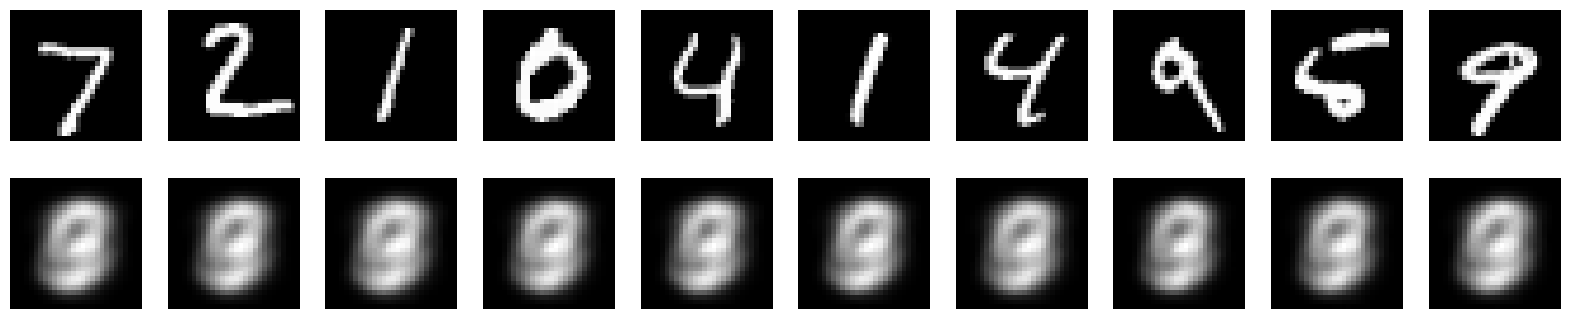

In [21]:
plt.figure(figsize=(20,4))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(
      x_test[i].reshape(28,28),
      cmap='grey'
  )
  plt.axis("off")
  ax=plt.subplot(2,10,i+11)
  plt.imshow(
      reconstructed[i].reshape(28,28),
      cmap='grey'
  )
  plt.axis("off")
plt.show()

##Lecture 29 Practical Exercise 2

In [22]:
#conditional VAE
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
x_train=x_train.astype('float32') / 255
x_test=x_test.astype('float32') / 255

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)
#one-hot vector encoding the labels (if an image belongs to class 0, the corresponding label will look like: [1,0,0,0,0,0,0,0,0,0])
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)
print(y_train[0])
# print("x_train (1st row):",x_train[0])

x_train shape: (60000, 784)
x_test shape: (10000, 784)
y_train shape: (60000, 10)
y_test shape: (10000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [23]:
class Sampling(layers.Layer):
  def call(self,inputs):
    z_mean,z_log_var=inputs
    epsilon=tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [24]:
latent_dim=16
num_classes=10

image_inputs=layers.Input(shape=(784,))
label_inputs=layers.Input(shape=(num_classes,))
encoder_inputs=layers.Concatenate()([image_inputs,label_inputs])
x=layers.Dense(256,activation='relu')(encoder_inputs)
z_mean=layers.Dense(latent_dim,name="z_mean")(x)
z_log_var=layers.Dense(latent_dim,name='z_log_var')(x)
z=Sampling()([z_mean,z_log_var])
encoder=Model(
    [image_inputs,label_inputs],
    [z_mean,z_log_var,z],
    name='encoder'
)

In [25]:
latent_inputs=layers.Input(shape=(latent_dim,))
label_decoder=layers.Input(shape=(num_classes,))
decoder_inputs=layers.Concatenate()([latent_inputs,label_decoder])
x=layers.Dense(256,activation='relu')(decoder_inputs)
decoder_outputs=layers.Dense(784,activation='sigmoid')(x)
decoder=Model([latent_inputs,label_decoder],decoder_outputs,name='decoder')

In [26]:
class CVAE(Model):
  def __init__(self,encoder,decoder):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
  def call(self,inputs):
    image,labels=inputs
    z_mean,z_log_var,z=self.encoder([image,labels])
    reconstruction=self.decoder([z,labels])
    return reconstruction
  def train_step(self,data):
    # if isinstance(data,tuple):
      (image,labels)=data[0]
      # print(data.shape)
      with tf.GradientTape() as tape:
        z_mean,z_log_var,z=self.encoder([image,labels])
        reconstruction=self.decoder([z,labels])
        #reconstruction loss (binary cross entropy as the data has been normalized to be between 0 and 1)
        reconstruction_loss=tf.reduce_mean(tf.keras.losses.binary_crossentropy(image,reconstruction))

        #kl divergence loss to ensure the encoder gaussian distribution is similar to the normal distribution from which epsilon is sampled
        kl_loss=-0.5 * tf.reduce_mean(
            1 + z_log_var
            -tf.square(z_mean)
            -tf.exp(z_log_var)
        ) #formula differs slightly from notes/class as the negative sign has been taken out common
        total_loss=reconstruction_loss+kl_loss
      grad=tape.gradient(
          total_loss,
          self.trainable_weights
      )
      self.optimizer.apply_gradients(
          zip(grad,self.trainable_weights)

      )
      return{
          "loss": total_loss,
          "reconstruction loss": reconstruction_loss,
          "KL divergence loss": kl_loss
      }



In [27]:
cvae=CVAE(encoder,decoder)
cvae.compile(optimizer='adam')

In [28]:
history=cvae.fit([x_train,y_train],epochs=15,batch_size=128)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - KL divergence loss: 3.0736e-05 - loss: 0.2356 - reconstruction loss: 0.2355
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 3.2847e-05 - loss: 0.2122 - reconstruction loss: 0.2122
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 5.1708e-05 - loss: 0.2169 - reconstruction loss: 0.2169
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 4.2462e-05 - loss: 0.2120 - reconstruction loss: 0.2119
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - KL divergence loss: 2.5688e-05 - loss: 0.2164 - reconstruction loss: 0.2164
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - KL divergence loss: 2.7066e-05 - loss: 0.2251 - reconstruction loss: 0.2251
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 1.3054e-05 - loss: 0.2278 - reconstruction loss: 0.2278
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - KL divergence loss: 7.6172e-06 - los

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

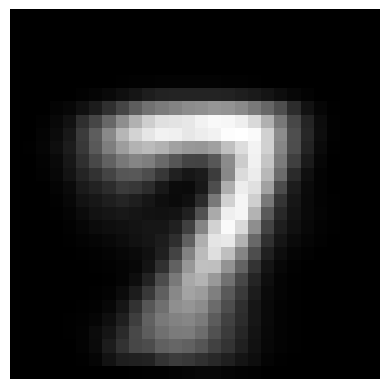

In [31]:
import numpy as np
z=np.random.normal(size=(1,latent_dim))
label=tf.keras.utils.to_categorical([7],num_classes=10)
generated=decoder.predict([z,label])
generated=generated.reshape(28,28)
plt.imshow(
    generated,
    cmap='grey'
)
plt.axis("off")
plt.show

In [33]:
z_mean,z_log_var,z=encoder.predict([x_test[:10],y_test[:10]])
reconstructed=decoder.predict([z,y_test[:10]])
reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


(10, 784)

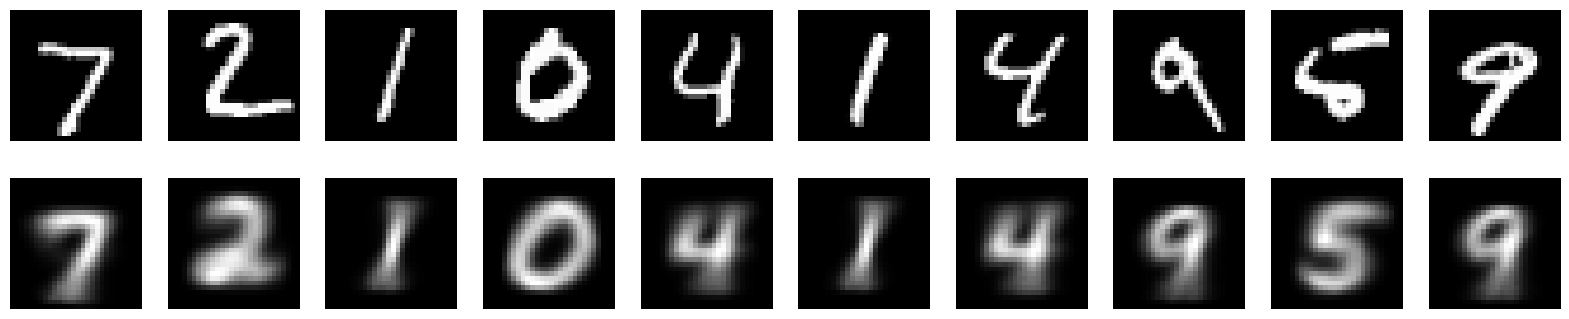

In [34]:
plt.figure(figsize=(20,4))
for i in range(10):
  ax=plt.subplot(2,10,i+1)
  plt.imshow(
      x_test[i].reshape(28,28),
      cmap='grey'
  )
  plt.axis("off")
  ax=plt.subplot(2,10,i+11)
  plt.imshow(
      reconstructed[i].reshape(28,28),
      cmap='grey'
  )
  plt.axis("off")
plt.show()

##Lecture 30 Practical Exercise 3

In [35]:
import tensorflow as tf
from keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [36]:
(x_train,_),(x_test,_)=tf.keras.datasets.mnist.load_data()

In [37]:
x_train=x_train.astype('float32') / 255
x_test=x_test.astype('float32') / 255

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
# print("x_train (1st row):",x_train[0])

x_train shape: (60000, 784)
x_test shape: (10000, 784)


In [40]:
#paramters
latent_dim=10
beta=[0.5,1,2,4,10]
epochs=15
batch_size=128

In [ ]:
class Sampling(layers.Layer):
  def call(self,inputs):
    z_mean,z_log_var=inputs
    epsilon=tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [42]:
def create_encoder():
  encoder_inputs=layers.Input(shape=(784,))
  x=layers.Dense(256,activation='relu')(encoder_inputs)
  z_mean=layers.Dense(latent_dim,name="z_mean")(x)
  z_log_var=layers.Dense(latent_dim,name='z_log_var')(x)
  z=Sampling()([z_mean,z_log_var])
  encoder=Model(
      encoder_inputs,
      [z_mean,z_log_var,z],
      name='encoder'
  )
  return encoder

In [44]:
def create_decoder():
  latent_inputs=layers.Input(shape=(latent_dim,))
  x=layers.Dense(256,activation='relu')(latent_inputs)
  decoder_outputs=layers.Dense(784,activation='sigmoid')(x)
  decoder=Model(latent_inputs,decoder_outputs,name='decoder')
  return decoder

In [51]:
class BVAE(Model):
  def __init__(
    self,
    encoder,
    decoder,
    beta):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.beta=beta
    self.total_loss_tracker=tf.keras.metrics.Mean(name='loss')
    self.recon_loss_tracker=tf.keras.metrics.Mean(name="recon_loss")
    self.kl_loss_tracker=tf.keras.metrics.Mean(name="kl_loss")
  @property
  def metrics(self):
    return [
        self.total_loss_tracker,
        self.recon_loss_tracker,
        self.kl_loss_tracker
    ]
  def train_step(self,data):
    with tf.GradientTape() as tape:
      z_mean,z_log_var,z=self.encoder(data)
      reconstruction=self.decoder(z)
      #reconstruction loss (binary cross entropy as the data has been normalized to be between 0 and 1)
      reconstruction_loss=tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(data,reconstruction),axis=-1))

      #kl divergence loss to ensure the encoder gaussian distribution is similar to the normal distribution from which epsilon is sampled
      kl_loss=-0.5 * tf.reduce_mean(tf.reduce_sum(
          1 + z_log_var
          -tf.square(z_mean)
          -tf.exp(z_log_var),
          axis=-1
      )) #formula differs slightly from notes/class as the negative sign has been taken out common
      total_loss=reconstruction_loss+self.beta * kl_loss
    grad=tape.gradient(
        total_loss,
        self.trainable_weights
    )
    self.optimizer.apply_gradients(
        zip(grad,self.trainable_weights)

    )
    self.total_loss_tracker.update_state(total_loss)
    self.recon_loss_tracker.update_state(reconstruction_loss)
    self.kl_loss_tracker.update_state(kl_loss)
    return{
        "loss": self.total_loss_tracker.result(),
        "reconstruction_loss": self.recon_loss_tracker.result(),
        "kl_loss": self.kl_loss_tracker.result()
    }

In [53]:
recon_losses=[]
kl_losses=[]
trained_models={}
for betav in beta:
  print(f"\nTraining with beta:{betav}")
  encoder=create_encoder()
  decoder=create_decoder()
  bvae=BVAE(encoder,decoder, betav)
  bvae.compile(optimizer=tf.keras.optimizers.Adam())
  history=bvae.fit(x_train,epochs=epochs,batch_size=batch_size,verbose=1)
  trained_models[betav]=bvae
  recon_losses.append(
      history.history['reconstruction_loss'][-1]
  )
  kl_losses.append(
      history.history['kl_loss'][-1]
  )


Training with beta:0.5
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - kl_loss: 6.9975 - loss: 32.4281 - reconstruction_loss: 28.9294
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 8.7120 - loss: 25.6889 - reconstruction_loss: 21.3329
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 9.3722 - loss: 24.7578 - reconstruction_loss: 20.0717
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 9.7270 - loss: 24.2865 - reconstruction_loss: 19.4231
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 9.9494 - loss: 23.9836 - reconstruction_loss: 19.0089
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 10.1499 - loss: 23.7806 - reconstruction_loss: 18.7056
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 10.2808 - loss: 23.6247 - reconstruction_loss: 18.4843
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 10.3933 - loss: 23.5084 - reconstruction_loss: 18.3117
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━

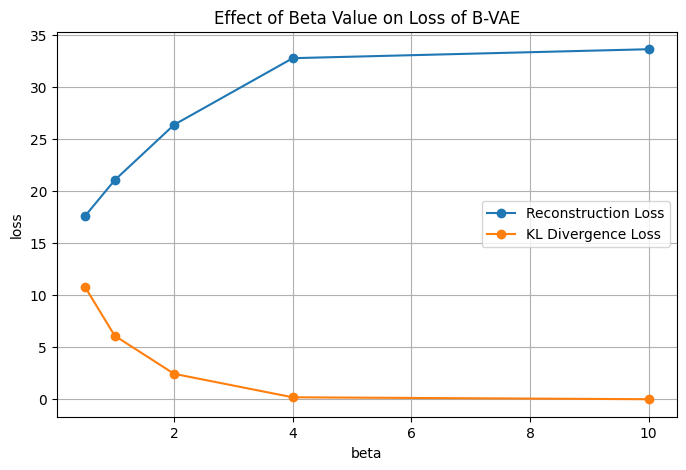

In [54]:
#compare loss values for different betav
plt.figure(figsize=(8,5))
plt.plot(
    beta,
    recon_losses,
    marker='o',
    label="Reconstruction Loss"
)
plt.plot(
    beta,
    kl_losses,
    marker='o',
    label="KL Divergence Loss"
)
plt.xlabel("beta")
plt.ylabel("loss")
plt.title("Effect of Beta Value on Loss of B-VAE")
plt.legend()
plt.grid()
plt.show()